# Zeek + vLLM (Qwen, AWQ int4) + LangGraph — local AI Network Security Monitoring

## 1. Check the GPU and install Python dependencies

In [1]:
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
Tesla T4, 15360 MiB, 7.5


In [2]:
%pip install -q -U vllm openai langgraph pydantic pandas bitsandbytes huggingface_hub
%pip -q uninstall -y torchaudio torchcodec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [1]:
import torch, vllm
assert torch.cuda.is_available(), "No GPU — set Runtime → Change runtime type → T4 GPU"
cc = torch.cuda.get_device_capability()
print(f"{torch.cuda.get_device_name(0)}  compute capability {cc[0]}.{cc[1]}  |  torch {torch.__version__}  |  vLLM {vllm.__version__}")
if cc < (8, 0):
    print("Turing/Volta GPU: bf16 unsupported → vLLM will run in float16 (--dtype half); attention backend will be TRITON_ATTN.")

Tesla T4  compute capability 7.5  |  torch 2.13.0+cu130  |  vLLM 0.30.0
Turing/Volta GPU: bf16 unsupported → vLLM will run in float16 (--dtype half); attention backend will be TRITON_ATTN.


## 2. Install Zeek (+ tcpdump) from the official Zeek OBS repository

In [2]:
%%bash
set -uo pipefail
export DEBIAN_FRONTEND=noninteractive
. /etc/os-release
REPO="xUbuntu_${VERSION_ID}"
echo "Ubuntu ${VERSION_ID} -> Zeek OBS repo ${REPO}"

echo "deb http://download.opensuse.org/repositories/security:/zeek/${REPO}/ /" \
  > /etc/apt/sources.list.d/security:zeek.list
curl -fsSL "https://download.opensuse.org/repositories/security:zeek/${REPO}/Release.key" \
  | gpg --dearmor > /etc/apt/trusted.gpg.d/security_zeek.gpg

apt-get update -qq > /dev/null 2>&1 || true
apt-get install -y -qq zeek tcpdump jq > /dev/null
/opt/zeek/bin/zeek --version

Ubuntu 24.04 -> Zeek OBS repo xUbuntu_24.04
/opt/zeek/bin/zeek version 9.0.0


In [3]:
import os, shutil, subprocess
os.environ["PATH"] = "/opt/zeek/bin:" + os.environ["PATH"]
assert shutil.which("zeek"), "zeek not found on PATH — check the install cell output above"
ZEEK_VERSION = subprocess.run(["zeek", "--version"], capture_output=True, text=True).stdout.strip()
print("Using:", ZEEK_VERSION)

Using: zeek version 9.0.0


## 3. Pick a quantization mode and start vLLM (text-only Qwen)



In [4]:
import subprocess, sys, time, os, json, secrets, urllib.request, urllib.error
from pathlib import Path
import torch
from huggingface_hub import hf_hub_download

QUANT          = "awq"            # "awq" | "gptq" | "bnb" | "fp16"
MODELS = {
    "awq":  "Qwen/Qwen2.5-7B-Instruct-AWQ",
    "gptq": "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4",
    "bnb":  "Qwen/Qwen2.5-7B-Instruct",       # quantized in-flight by --quantization bitsandbytes
    "fp16": "Qwen/Qwen2.5-3B-Instruct",
}
MODEL_ID       = MODELS[QUANT]
SERVED_NAME    = "qwen"
PORT           = 8000
CTX            = 8192                 # max-model-len; drop to 4096 if you hit OOM
BATCH          = 8                    # max concurrent sequences (the graph fans research out in parallel)
GPU_MEM_UTIL   = 0.90
ENFORCE_EAGER  = True                 # no CUDA-graph capture → faster start, less VRAM on a T4
EXPOSE_PUBLIC_URL = True              # True → cloudflared tunnel + API key (see next cell)

major, minor = torch.cuda.get_device_capability()
DTYPE = "half" if major < 8 else "bfloat16"
print(f"GPU sm_{major}{minor} -> dtype={DTYPE}")

# ---- text-only guard: inspect the HF config before loading anything --------------------------
cfg = json.load(open(hf_hub_download(MODEL_ID, "config.json")))
archs = cfg.get("architectures", [])
MULTIMODAL_MARKERS = ("VL", "Vision", "Omni", "Audio", "Image", "Video")
if any(m in a for a in archs for m in MULTIMODAL_MARKERS) or "vision_config" in cfg:
    raise ValueError(f"{MODEL_ID} is a multimodal model ({archs}) — this pipeline only uses text models.")
qc = cfg.get("quantization_config", {})
print(f"model={MODEL_ID}  arch={archs}  checkpoint quant={qc.get('quant_method', 'none')}"
      f"{' (bits=' + str(qc.get('bits')) + ')' if qc.get('bits') else ''}  runtime quant={QUANT}")

VLLM_LOG = Path("/content/vllm_server.log")
API_KEY = secrets.token_urlsafe(24) if EXPOSE_PUBLIC_URL else None

cmd = [
    "vllm", "serve", MODEL_ID,
    "--served-model-name", SERVED_NAME,
    "--dtype", DTYPE,
    "--max-model-len", str(CTX),
    "--max-num-seqs", str(BATCH),
    "--gpu-memory-utilization", str(GPU_MEM_UTIL),
    "--tensor-parallel-size", "1",
    "--host", "127.0.0.1", "--port", str(PORT),
]
if QUANT == "bnb":
    cmd += ["--quantization", "bitsandbytes"]      # in-flight 4-bit (nf4) quantization of the fp16 checkpoint
if ENFORCE_EAGER:
    cmd.append("--enforce-eager")
if API_KEY:
    cmd += ["--api-key", API_KEY]
print(" ".join(cmd))

GPU sm_75 -> dtype=half
model=Qwen/Qwen2.5-7B-Instruct-AWQ  arch=['Qwen2ForCausalLM']  checkpoint quant=awq (bits=4)  runtime quant=awq
vllm serve Qwen/Qwen2.5-7B-Instruct-AWQ --served-model-name qwen --dtype half --max-model-len 8192 --max-num-seqs 8 --gpu-memory-utilization 0.9 --tensor-parallel-size 1 --host 127.0.0.1 --port 8000 --enforce-eager --api-key PvFLqXyCUb2FZfpzbwA6NSU13TJZbhNv


In [5]:
def wait_for_vllm(proc: subprocess.Popen, timeout_s: int = 1500) -> None:
    url = f"http://127.0.0.1:{PORT}/health"
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        if proc.poll() is not None:
            print(VLLM_LOG.read_text()[-4000:])
            raise RuntimeError("vLLM exited during startup — see log tail above")
        try:
            if urllib.request.urlopen(url, timeout=3).status == 200:
                print(f"vLLM ready after {time.time()-t0:.0f}s")
                return
        except (urllib.error.URLError, ConnectionError, OSError):
            pass
        time.sleep(5)
    print(VLLM_LOG.read_text()[-4000:])
    raise TimeoutError("vLLM did not become healthy in time")


if "vllm_proc" in globals() and vllm_proc.poll() is None:
    vllm_proc.terminate(); vllm_proc.wait(timeout=30)

vllm_proc = subprocess.Popen(cmd, stdout=VLLM_LOG.open("w"), stderr=subprocess.STDOUT,
                             env={**os.environ, "VLLM_LOGGING_LEVEL": "INFO"})
wait_for_vllm(vllm_proc)

vLLM ready after 80s


In [6]:
from openai import OpenAI
BASE_URL = f"http://127.0.0.1:{PORT}/v1"
client = OpenAI(base_url=BASE_URL, api_key=API_KEY or "EMPTY", timeout=600)
r = client.chat.completions.create(model=SERVED_NAME, max_tokens=40, temperature=0,
                                   messages=[{"role": "user", "content": "In one sentence: what is Zeek?"}],
                                   extra_body={"chat_template_kwargs": {"enable_thinking": False}})
print(r.choices[0].message.content)
!grep -iE "quantization|attention backend|Using .* backend|KV cache|dtype" /content/vllm_server.log | grep -v WARNING | head -n 6

Zeek is an open-source network security monitoring tool that performs log analysis and packet capture, often used for security auditing and forensic analysis.
(APIServer pid=9540) INFO 09-29 10:49:35 [api_utils.py:286] non-default args: {'model_tag': 'Qwen/Qwen2.5-7B-Instruct-AWQ', 'host': '127.0.0.1', 'api_key': '***', 'model': 'Qwen/Qwen2.5-7B-Instruct-AWQ', 'dtype': 'half', 'max_model_len': 8192, 'enforce_eager': True, 'served_model_name': ['qwen'], 'gpu_memory_utilization': 0.9, 'max_num_seqs': 8}
(EngineCore pid=9671) INFO 09-29 10:49:58 [core.py:123] Initializing a V1 LLM engine (v0.30.0) with config: model='Qwen/Qwen2.5-7B-Instruct-AWQ', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct-AWQ', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=False, dtype=torch.float16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_para

In [7]:
PUBLIC_URL = None
if EXPOSE_PUBLIC_URL:
    import re, shutil
    if shutil.which("cloudflared") is None:
        subprocess.run("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb "
                       "&& dpkg -i cloudflared-linux-amd64.deb > /dev/null", shell=True, check=True)
    CF_LOG = Path("/content/cloudflared.log")
    tunnel = subprocess.Popen(["cloudflared", "tunnel", "--url", f"http://127.0.0.1:{PORT}", "--no-autoupdate"],
                              stdout=CF_LOG.open("w"), stderr=subprocess.STDOUT)
    for _ in range(60):
        time.sleep(2)
        m = re.search(r"https://[-a-z0-9]+\.trycloudflare\.com", CF_LOG.read_text())
        if m:
            PUBLIC_URL = m.group(0); break
    print("public base URL:", f"{PUBLIC_URL}/v1" if PUBLIC_URL else CF_LOG.read_text()[-1500:])
    print("API key:", API_KEY)
else:
    print("EXPOSE_PUBLIC_URL is False — server is local only")

public base URL: https://ink-asn-champagne-silent.trycloudflare.com/v1
API key: PvFLqXyCUb2FZfpzbwA6NSU13TJZbhNv


## 4. Get traffic

In [8]:
from pathlib import Path
import subprocess, time, shlex, socket, concurrent.futures

SOURCE = "live"            # "live" | "upload" | "url"
CAPTURE_SECONDS = 30
PCAP_URL = ""              # only used when SOURCE == "url"

WORK = Path("/content/nsm")
WORK.mkdir(parents=True, exist_ok=True)


def default_interface() -> str:
    out = subprocess.run(["ip", "route", "show", "default"], capture_output=True, text=True).stdout.split()
    return out[out.index("dev") + 1] if "dev" in out else "eth0"


def generate_sample_traffic():
    """Benign HTTP/HTTPS/DNS so a live capture on Colab has something to analyze."""
    urls = [
        "http://example.com",
        "http://neverssl.com",
        "https://www.zeek.org",
        "https://github.com/zeek/zeek",
        "https://docs.zeek.org",
    ]
    def hit(u):
        subprocess.run(["curl", "-s", "-m", "8", "-o", "/dev/null", u], capture_output=True)
        try:
            socket.getaddrinfo(u.split("/")[2], 443)
        except OSError:
            pass
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as ex:
        list(ex.map(hit, urls))


def capture_live(seconds: int, out: Path) -> Path:
    iface = default_interface()
    print(f"Capturing {seconds}s on {iface} -> {out}")
    proc = subprocess.Popen(["tcpdump", "-i", iface, "-U", "-w", str(out)], stderr=subprocess.DEVNULL)
    time.sleep(2)
    t_end = time.time() + seconds
    while time.time() < t_end:
        generate_sample_traffic()
        time.sleep(3)
    proc.terminate()
    proc.wait(timeout=10)
    size = out.stat().st_size if out.exists() else 0
    print(f"Saved {out} ({size:,} bytes)")
    if size < 1000:
        print("⚠️  Capture is almost empty — live capture may be blocked on this runtime. Use SOURCE='upload' or 'url'.")
    return out


if SOURCE == "live":
    PCAP = capture_live(CAPTURE_SECONDS, WORK / "live.pcap")
elif SOURCE == "upload":
    from google.colab import files
    uploaded = files.upload()
    name = next(iter(uploaded))
    PCAP = WORK / name
    PCAP.write_bytes(uploaded[name])
elif SOURCE == "url":
    assert PCAP_URL, "Set PCAP_URL"
    PCAP = WORK / (Path(PCAP_URL).name or "download.pcap")
    subprocess.run(["wget", "-q", "-O", str(PCAP), PCAP_URL], check=True)
else:
    raise ValueError(SOURCE)

print("PCAP:", PCAP)

Capturing 30s on eth0 -> /content/nsm/live.pcap
Saved /content/nsm/live.pcap (1,363,666 bytes)
PCAP: /content/nsm/live.pcap


## 5. Run Zeek on the pcap (JSON logs)

In [9]:
def run_zeek(pcap: Path, log_dir: Path) -> Path:
    """Run Zeek offline on a pcap and write JSON logs into log_dir."""
    log_dir.mkdir(parents=True, exist_ok=True)
    for old in log_dir.glob("*.log"):
        old.unlink()

    cmd = ["zeek", "-C", "-r", str(pcap.resolve()), "LogAscii::use_json=T", "local"]
    res = subprocess.run(cmd, cwd=log_dir, capture_output=True, text=True)
    if res.returncode != 0:
        print(res.stdout, res.stderr)
        raise RuntimeError("Zeek failed — see output above")
    if res.stderr.strip():
        print("Zeek warnings:\n", res.stderr.strip())
    produced = sorted(p.name for p in log_dir.glob("*.log"))
    print("Zeek logs:", ", ".join(produced) or "(none)")
    return log_dir


LOG_DIR = run_zeek(PCAP, WORK / "zeek_logs")

Zeek logs: capture_loss.log, conn.log, dns.log, files.log, http.log, known_hosts.log, known_services.log, loaded_scripts.log, packet_filter.log, software.log, ssl.log, stats.log, weird.log


In [10]:
!head -n 3 /content/nsm/zeek_logs/conn.log 2>/dev/null | jq -c '{ts, "src": ."id.orig_h", "dst": ."id.resp_h", "dport": ."id.resp_p", proto, service, conn_state}'

{"ts":1790679066.742807,"src":"172.28.0.12","dst":"104.20.23.154","dport":80,"proto":"tcp","service":"http","conn_state":"SF"}
{"ts":1790679066.769162,"src":"172.28.0.12","dst":"34.223.124.45","dport":80,"proto":"tcp","service":null,"conn_state":"S0"}
{"ts":1790679066.783534,"src":"172.28.0.12","dst":"104.16.253.120","dport":443,"proto":"tcp","service":"ssl","conn_state":"SF"}


## 6. Parse logs & deterministic pre-analysis

In [11]:
import json, ipaddress
from collections import Counter, defaultdict
from statistics import mean
import pandas as pd


def load_zeek_logs(log_dir: Path) -> dict[str, list[dict]]:
    """Read every *.log (JSON lines) in log_dir -> {"conn": [...], "dns": [...], ...}"""
    logs: dict[str, list[dict]] = {}
    for p in sorted(Path(log_dir).glob("*.log")):
        rows = []
        with open(p) as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
        logs[p.stem] = rows
    return logs


def is_private(ip: str) -> bool:
    try:
        a = ipaddress.ip_address(ip)
        return a.is_private or a.is_loopback or a.is_link_local
    except ValueError:
        return False


def _top(counter: Counter, n: int) -> list[dict]:
    return [{"value": k, "count": v} for k, v in counter.most_common(n)]


def build_stats(logs: dict[str, list[dict]], top_n: int = 10) -> dict:
    conn = logs.get("conn", [])
    dns = logs.get("dns", [])
    http = logs.get("http", [])
    ssl = logs.get("ssl", [])
    notices = logs.get("notice", [])
    weird = logs.get("weird", [])
    flags: list[dict] = []

    # ---- time range ---------------------------------------------------------
    ts = [r["ts"] for r in conn if isinstance(r.get("ts"), (int, float))]
    time_range = {"start": min(ts) if ts else None, "end": max(ts) if ts else None,
                  "duration_s": round(max(ts) - min(ts), 2) if ts else 0.0}

    # ---- conn.log -----------------------------------------------------------
    proto, service, states, dports = Counter(), Counter(), Counter(), Counter()
    bytes_by_pair: Counter = Counter()
    dst_ports_by_src_dst: dict[tuple, set] = defaultdict(set)
    dst_hosts_by_src_port: dict[tuple, set] = defaultdict(set)
    orig_hosts, resp_hosts = set(), set()
    long_conns = []
    total_orig = total_resp = 0
    for r in conn:
        s, d, p = r.get("id.orig_h", "?"), r.get("id.resp_h", "?"), r.get("id.resp_p", 0)
        proto[r.get("proto", "?")] += 1
        service[r.get("service") or "-"] += 1
        states[r.get("conn_state", "?")] += 1
        dports[p] += 1
        ob, rb = r.get("orig_bytes") or 0, r.get("resp_bytes") or 0
        total_orig += ob; total_resp += rb
        bytes_by_pair[(s, d)] += ob + rb
        orig_hosts.add(s); resp_hosts.add(d)
        dst_ports_by_src_dst[(s, d)].add(p)
        if r.get("conn_state") in ("S0", "REJ", "RSTO", "RSTOS0", "OTH"):
            dst_hosts_by_src_port[(s, p)].add(d)
        if (r.get("duration") or 0) > 600:
            long_conns.append({"src": s, "dst": d, "dport": p, "duration_s": round(r["duration"], 1),
                               "bytes": ob + rb, "service": r.get("service")})

    for (s, d), ports in dst_ports_by_src_dst.items():
        if len(ports) >= 20:
            flags.append({"rule": "possible_port_scan", "hosts": [s, d],
                          "detail": f"{s} touched {len(ports)} distinct ports on {d}"})
    for (s, p), hosts in dst_hosts_by_src_port.items():
        if len(hosts) >= 20:
            flags.append({"rule": "possible_host_sweep", "hosts": [s],
                          "detail": f"{s} probed port {p} on {len(hosts)} hosts with failed/unanswered connections"})
    for lc in long_conns[:5]:
        flags.append({"rule": "long_lived_connection", "hosts": [lc["src"], lc["dst"]],
                      "detail": f"{lc['src']} -> {lc['dst']}:{lc['dport']} lasted {lc['duration_s']}s ({lc['bytes']} bytes)"})

    top_pairs = [{"src": s, "dst": d, "bytes": b} for (s, d), b in bytes_by_pair.most_common(top_n)]
    internal = sorted(h for h in orig_hosts | resp_hosts if is_private(h))
    external_count = len([h for h in orig_hosts | resp_hosts if not is_private(h)])

    # ---- dns.log ------------------------------------------------------------
    queries = Counter(r.get("query") for r in dns if r.get("query"))
    qtypes = Counter(r.get("qtype_name", "?") for r in dns)
    rcodes = Counter(r.get("rcode_name", "?") for r in dns)
    nx = rcodes.get("NXDOMAIN", 0)
    nx_ratio = round(nx / len(dns), 3) if dns else 0.0
    long_labels = sorted({r["query"] for r in dns if r.get("query") and max(len(x) for x in r["query"].split(".")) > 50})
    avg_qlen = round(mean(len(q) for q in queries.elements()), 1) if queries else 0
    if long_labels:
        flags.append({"rule": "possible_dns_tunneling", "hosts": [],
                      "detail": f"{len(long_labels)} queries with a label > 50 chars, e.g. {long_labels[0][:80]}"})
    if len(dns) >= 20 and nx_ratio > 0.3:
        flags.append({"rule": "high_nxdomain_ratio", "hosts": [],
                      "detail": f"{nx_ratio:.0%} of {len(dns)} DNS responses were NXDOMAIN (possible DGA / misconfig)"})
    if qtypes.get("TXT", 0) >= 10:
        flags.append({"rule": "many_txt_queries", "hosts": [], "detail": f"{qtypes['TXT']} TXT queries"})

    # ---- http.log -----------------------------------------------------------
    hosts = Counter(r.get("host") for r in http if r.get("host"))
    methods = Counter(r.get("method", "?") for r in http)
    codes = Counter(r.get("status_code", 0) for r in http)
    uas = Counter(r.get("user_agent", "") for r in http)
    odd_ua = [ua for ua in uas if ua and not any(k in ua for k in ("Mozilla", "curl", "Wget", "python", "Go-http", "okhttp", "Dalvik", "Java", "Apache"))]
    ext_plain = [r for r in http if not is_private(r.get("id.resp_h", ""))]
    if ext_plain:
        flags.append({"rule": "plaintext_http_to_external", "hosts": sorted({r.get("id.orig_h") for r in ext_plain}),
                      "detail": f"{len(ext_plain)} unencrypted HTTP requests to external hosts ({', '.join(list(hosts)[:5])})"})
    big_posts = [r for r in http if r.get("method") == "POST" and (r.get("request_body_len") or 0) > 1_000_000]
    if big_posts:
        flags.append({"rule": "large_http_upload", "hosts": sorted({r.get("id.orig_h") for r in big_posts}),
                      "detail": f"{len(big_posts)} POST requests > 1 MB (possible exfiltration)"})

    # ---- ssl.log ------------------------------------------------------------
    sni = Counter(r.get("server_name") for r in ssl if r.get("server_name"))
    versions = Counter(r.get("version", "?") for r in ssl)
    bad_val = [r for r in ssl if r.get("validation_status") not in (None, "ok")]
    legacy = [r for r in ssl if r.get("version") in ("SSLv2", "SSLv3", "TLSv10", "TLSv11")]
    if bad_val:
        flags.append({"rule": "tls_certificate_validation_failure", "hosts": sorted({r.get("id.resp_h") for r in bad_val}),
                      "detail": f"{len(bad_val)} TLS sessions failed cert validation: " + ", ".join(sorted({str(r.get('validation_status')) for r in bad_val})[:3])})
    if legacy:
        flags.append({"rule": "legacy_tls_version", "hosts": sorted({r.get("id.resp_h") for r in legacy}),
                      "detail": f"{len(legacy)} sessions used {', '.join(sorted({r['version'] for r in legacy}))}"})

    # ---- notice / weird -----------------------------------------------------
    notice_list = [{"note": r.get("note"), "msg": r.get("msg"), "src": r.get("src"), "dst": r.get("dst")} for r in notices][:25]
    if notice_list:
        flags.append({"rule": "zeek_notice", "hosts": sorted({n["src"] for n in notice_list if n.get("src")}),
                      "detail": f"{len(notices)} Zeek notices: " + ", ".join(sorted({str(n['note']) for n in notice_list}))})
    weird_counts = Counter(r.get("name", "?") for r in weird)
    if len(weird) > 50:
        flags.append({"rule": "weird_burst", "hosts": [], "detail": f"{len(weird)} weird.log entries; top: {weird_counts.most_common(3)}"})

    return {
        "log_counts": {k: len(v) for k, v in logs.items()},
        "time_range": time_range,
        "conn": {
            "total": len(conn), "by_proto": dict(proto), "by_service": _top(service, top_n),
            "conn_states": dict(states), "top_dest_ports": _top(dports, top_n),
            "top_talkers_by_bytes": top_pairs, "total_orig_bytes": total_orig, "total_resp_bytes": total_resp,
            "internal_hosts": internal[:50], "external_host_count": external_count,
            "long_connections": long_conns[:10],
        },
        "dns": {"total": len(dns), "unique_domains": len(queries), "top_queries": _top(queries, top_n),
                "qtypes": dict(qtypes), "rcodes": dict(rcodes), "nxdomain_ratio": nx_ratio,
                "avg_query_len": avg_qlen, "long_label_queries": long_labels[:10]},
        "http": {"total": len(http), "top_hosts": _top(hosts, top_n), "methods": dict(methods),
                 "status_codes": {str(k): v for k, v in codes.items()}, "unusual_user_agents": odd_ua[:10]},
        "ssl": {"total": len(ssl), "top_sni": _top(sni, top_n), "versions": dict(versions),
                "validation_failures": len(bad_val)},
        "notices": notice_list,
        "weird": _top(weird_counts, top_n),
        "heuristic_flags": flags,
    }


LOGS = load_zeek_logs(LOG_DIR)
STATS = build_stats(LOGS)
print(json.dumps({k: STATS[k] for k in ("log_counts", "time_range")}, indent=2))
print("\nHeuristic flags:")
display(pd.DataFrame(STATS["heuristic_flags"]) if STATS["heuristic_flags"] else "none")

{
  "log_counts": {
    "capture_loss": 1,
    "conn": 87,
    "dns": 60,
    "files": 8,
    "http": 8,
    "known_hosts": 2,
    "known_services": 2,
    "loaded_scripts": 551,
    "packet_filter": 1,
    "software": 4,
    "ssl": 9,
    "stats": 2,
    "weird": 1
  },
  "time_range": {
    "start": 1790679064.781735,
    "end": 1790679094.980548,
    "duration_s": 30.2
  }
}

Heuristic flags:


,rule,hosts,detail
0,plaintext_http_to_external,[172.28.0.12],4 unencrypted HTTP requests to external hosts ...


## 7. Pydantic output schema


In [12]:
from enum import Enum
from typing import Optional, Any
from pydantic import BaseModel, Field, ValidationError


class Severity(str, Enum):
    info = "info"
    low = "low"
    medium = "medium"
    high = "high"
    critical = "critical"


class Category(str, Enum):
    reconnaissance = "reconnaissance"
    command_and_control = "command_and_control"
    data_exfiltration = "data_exfiltration"
    malware = "malware"
    dns_anomaly = "dns_anomaly"
    insecure_protocol = "insecure_protocol"
    misconfiguration = "misconfiguration"
    policy_violation = "policy_violation"
    anomaly = "anomaly"
    informational = "informational"


class CaptureSummary(BaseModel):
    """Deterministic numbers computed from the Zeek logs (not LLM-generated)."""
    total_connections: int
    duration_seconds: float
    top_protocols: list[str]
    top_services: list[str]
    internal_hosts: list[str]
    external_host_count: int
    dns_queries: int
    http_requests: int
    tls_sessions: int
    zeek_notices: int
    heuristic_flag_count: int


class TriageNotes(BaseModel):
    notable_observations: list[str] = Field(description="Short, evidence-backed observations about the traffic")
    areas_to_investigate: list[str] = Field(description="Which logs/hosts/behaviours deserve a closer look and why")
    looks_benign_overall: bool


class Finding(BaseModel):
    id: str = Field(description="Identifier like F-001 (will be normalized)")
    title: str
    severity: Severity
    category: Category
    confidence: float = Field(description="0.0 – 1.0")
    description: str = Field(description="What was observed and why it matters")
    evidence: list[str] = Field(description="Concrete facts from the Zeek stats/flags that support this finding")
    affected_hosts: list[str]
    supporting_zeek_logs: list[str] = Field(description="e.g. conn, dns, http, ssl, notice, weird")
    mitre_attack_techniques: list[str] = Field(description="MITRE ATT&CK IDs like T1046, empty if not applicable")


class FindingsList(BaseModel):
    findings: list[Finding]


class Solution(BaseModel):
    finding_id: str
    solution_exists: bool = Field(description="False if no reliable, known remediation exists for this finding")
    summary: str
    remediation_steps: list[str] = Field(description="Concrete, ordered steps an operator can take")
    zeek_detection_hint: Optional[str] = Field(description="Zeek script/policy/package to enable for ongoing detection, if any")
    references: list[str] = Field(description="Names or URLs of standards, vendor docs, Zeek docs/packages, CVEs")
    residual_risk: str = Field(description="What remains risky after applying the remediation")


class ReportNarrative(BaseModel):
    executive_summary: str = Field(description="3-6 sentences for a non-technical reader")
    overall_risk: Severity
    prioritized_recommendations: list[str] = Field(description="Most important actions first")


class NetworkReport(BaseModel):
    report_id: str
    generated_at: str
    source: str
    zeek_version: str
    model: str
    capture_summary: CaptureSummary
    heuristic_flags: list[dict[str, Any]]
    triage: TriageNotes
    findings: list[Finding]
    solutions: list[Solution]
    executive_summary: str
    overall_risk: Severity
    prioritized_recommendations: list[str]


print(json.dumps(NetworkReport.model_json_schema(), indent=1)[:600], "...")

{
 "$defs": {
  "CaptureSummary": {
   "description": "Deterministic numbers computed from the Zeek logs (not LLM-generated).",
   "properties": {
    "total_connections": {
     "title": "Total Connections",
     "type": "integer"
    },
    "duration_seconds": {
     "title": "Duration Seconds",
     "type": "number"
    },
    "top_protocols": {
     "items": {
      "type": "string"
     },
     "title": "Top Protocols",
     "type": "array"
    },
    "top_services": {
     "items": {
      "type": "string"
     },
     "title": "Top Services",
     "type": "array"
    },
    "internal_ho ...


## 8. Structured-output client for vLLM

In [13]:
import openai
from openai import OpenAI

client = OpenAI(base_url=BASE_URL, api_key=API_KEY or "EMPTY", timeout=600)

MAX_PROMPT_CHARS = 14_000
TEMPERATURE = 0.2


def _structured_kwargs(schema_json: dict, name: str, variant: int) -> dict:
    """Different vLLM versions expose constrained decoding under different names — try them in order."""
    if variant == 0:
        return {"response_format": {"type": "json_schema", "json_schema": {"name": name, "schema": schema_json}}}
    if variant == 1:
        return {"extra_body": {"structured_outputs": {"json": schema_json}}}
    return {"extra_body": {"guided_json": schema_json}}


_STRUCTURED_VARIANT = 0


def call_structured(schema: type[BaseModel], system: str, user: str, max_tokens: int = 2048, attempts: int = 3) -> BaseModel:
    """One schema-constrained call to the local Qwen model → validated Pydantic instance."""
    global _STRUCTURED_VARIANT
    schema_json = schema.model_json_schema()
    if len(user) > MAX_PROMPT_CHARS:
        user = user[:MAX_PROMPT_CHARS] + "\n...[truncated]"
    messages = [
        {"role": "system", "content": system + "\nRespond with a single JSON object that matches the required schema. No prose, no markdown."},
        {"role": "user", "content": user},
    ]
    last_err = None
    for attempt in range(attempts):
        kwargs = _structured_kwargs(schema_json, schema.__name__, _STRUCTURED_VARIANT)
        extra = kwargs.pop("extra_body", {})
        extra.setdefault("chat_template_kwargs", {"enable_thinking": False})
        try:
            resp = client.chat.completions.create(
                model=SERVED_NAME, messages=messages, temperature=TEMPERATURE,
                max_tokens=max_tokens, extra_body=extra, **kwargs)
        except openai.BadRequestError as e:
            if _STRUCTURED_VARIANT < 2:
                _STRUCTURED_VARIANT += 1
                print(f"  structured-output style {_STRUCTURED_VARIANT-1} rejected, trying style {_STRUCTURED_VARIANT}: {str(e)[:120]}")
                continue
            raise
        choice = resp.choices[0]
        text = choice.message.content or ""
        try:
            return schema.model_validate_json(text)
        except ValidationError as e:
            last_err = e
            hint = "Output was cut off at max_tokens — be more concise." if choice.finish_reason == "length" else ""
            messages += [{"role": "assistant", "content": text},
                         {"role": "user", "content": f"That JSON failed validation: {e.errors()[:3]}. {hint} Return the corrected JSON object only."}]
            max_tokens = min(int(max_tokens * 1.5), 4096)
    raise RuntimeError(f"{schema.__name__}: no valid output after {attempts} attempts: {last_err}")


class _Ping(BaseModel):
    tool: str
    purpose: str
    confidence: float

print(call_structured(_Ping, "You are a security analyst.", "Describe Zeek in one line as JSON."))

tool='Zeek' purpose='Network security event detector and log analyzer.' confidence=100.0


## 9. LangGraph pipeline


In [14]:
import operator, uuid
from datetime import datetime, timezone
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.checkpoint.memory import MemorySaver

MAX_RETRIES = 2


class PipelineState(TypedDict, total=False):
    log_dir: str
    source: str
    stats: dict
    capture_summary: dict
    triage: dict
    findings: list[dict]
    solutions: Annotated[list[dict], operator.add]
    narrative: dict
    report: dict
    validation_problems: list[str]
    retries: int
    errors: Annotated[list[str], operator.add]


class ResearchInput(TypedDict):
    """Payload sent to one parallel `research_one` branch."""
    finding: dict


# ---- prompts ----------------------------------------------------------------
TRIAGE_SYSTEM = """You are a senior network security analyst reviewing statistics that Zeek produced from a packet capture.
Stay strictly grounded in the numbers and heuristic flags you are given; do not invent hosts, ports or events.
Note both suspicious and clearly benign patterns. Be concise."""

DETECT_SYSTEM = """You are a network security analyst producing findings from Zeek log statistics, heuristic flags and triage notes.
Rules:
- Every finding must cite concrete evidence present in the input (counts, hosts, ports, domains, flag details).
- Do not fabricate. If the traffic looks benign, return zero findings or only 'informational' ones.
- Severity: info = observation, low = hygiene issue, medium = should be fixed, high = likely compromise/active attack, critical = confirmed damage or exfiltration.
- Use MITRE ATT&CK technique IDs where they genuinely apply.
- Merge duplicates; prefer fewer, well-supported findings over many weak ones."""

RESEARCH_SYSTEM = """You are a security engineer. For the given finding, determine whether a reliable, known solution exists and describe it.
- If a standard remediation exists (config change, patch, network policy, Zeek detection script/package), set solution_exists=true and give concrete ordered steps.
- If the finding is inherently ambiguous or there is no reliable fix (e.g. needs manual investigation, or is informational), set solution_exists=false and explain what investigation is needed instead.
- Include a Zeek-specific detection hint when one exists (built-in policy scripts under policy/, notice framework, or a Zeek package).
- Only list references you are confident are real; use the web research notes if provided."""

NARRATE_SYSTEM = """You write the executive narrative of a network security monitoring report. Be factual, calm, and specific.
Overall risk must be consistent with the findings' severities (no findings above 'low' -> overall risk low or info)."""


# ---- helpers ------------------------------------------------------------------
def make_capture_summary(stats: dict) -> CaptureSummary:
    c = stats["conn"]
    return CaptureSummary(
        total_connections=c["total"],
        duration_seconds=float(stats["time_range"]["duration_s"] or 0),
        top_protocols=[k for k, _ in sorted(c["by_proto"].items(), key=lambda kv: -kv[1])[:5]],
        top_services=[x["value"] for x in c["by_service"][:5]],
        internal_hosts=c["internal_hosts"][:20],
        external_host_count=c["external_host_count"],
        dns_queries=stats["dns"]["total"],
        http_requests=stats["http"]["total"],
        tls_sessions=stats["ssl"]["total"],
        zeek_notices=len(stats["notices"]),
        heuristic_flag_count=len(stats["heuristic_flags"]),
    )


def _j(obj) -> str:
    return json.dumps(obj, default=str)


# ---- nodes --------------------------------------------------------------------
def ingest_node(state: PipelineState) -> dict:
    print("▶ ingest")
    logs = load_zeek_logs(Path(state["log_dir"]))
    stats = build_stats(logs)
    return {"stats": stats, "capture_summary": make_capture_summary(stats).model_dump(),
            "findings": [], "retries": 0}


def triage_node(state: PipelineState) -> dict:
    print("▶ triage (LLM)")
    st = {k: v for k, v in state["stats"].items() if k != "notices"}
    notes = call_structured(TriageNotes, TRIAGE_SYSTEM, _j({"capture_summary": state["capture_summary"], "stats": st,
                                                          "notice_count": len(state["stats"]["notices"])}), max_tokens=1200)
    return {"triage": notes.model_dump()}


def detect_node(state: PipelineState) -> dict:
    print("▶ detect (LLM)")
    st = state["stats"]
    payload = {"capture_summary": state["capture_summary"], "triage": state["triage"],
               "heuristic_flags": st["heuristic_flags"], "notices": st["notices"],

               "evidence": {"top_talkers": st["conn"]["top_talkers_by_bytes"][:5], "top_dest_ports": st["conn"]["top_dest_ports"][:8],
                            "conn_states": st["conn"]["conn_states"], "long_connections": st["conn"]["long_connections"][:5],
                            "dns": {k: st["dns"][k] for k in ("total", "unique_domains", "top_queries", "nxdomain_ratio", "long_label_queries")},
                            "http": {k: st["http"][k] for k in ("total", "top_hosts", "methods", "unusual_user_agents")},
                            "ssl": st["ssl"], "weird": st["weird"][:5]}}
    result = call_structured(FindingsList, DETECT_SYSTEM, _j(payload), max_tokens=3000)
    findings = []
    for i, f in enumerate(result.findings, start=1):
        f.id = f"F-{i:03d}"
        f.confidence = max(0.0, min(1.0, f.confidence))
        findings.append(f.model_dump(mode="json"))
    print(f"  {len(findings)} finding(s)")
    return {"findings": findings}


def fan_out_research(state: PipelineState):
    """Conditional edge: one Send per finding that still has no solution → parallel branches; none → narrate."""
    done = {sol["finding_id"] for sol in state.get("solutions", [])}
    todo = [f for f in state.get("findings", []) if f["id"] not in done]
    if not todo:
        return "narrate"
    print(f"▶ research: fanning out {len(todo)} finding(s) in parallel")
    return [Send("research_one", {"finding": f}) for f in todo]


def research_one(state: ResearchInput) -> dict:
    f = state["finding"]
    print(f"  {f['id']}: {f['title']}")
    try:
        sol = call_structured(Solution, RESEARCH_SYSTEM, _j({"finding": f}), max_tokens=1500)
    except Exception as e:
        print(f"  {f['id']} research failed: {str(e)[:160]}")
        return {"errors": [f"research {f['id']}: {str(e)[:200]}"]}
    sol.finding_id = f["id"]
    return {"solutions": [sol.model_dump(mode="json")]}


def narrate_node(state: PipelineState) -> dict:
    print("▶ narrate (LLM)")
    brief = [{"id": f["id"], "title": f["title"], "severity": f["severity"], "category": f["category"],
              "solution_exists": next((s["solution_exists"] for s in state.get("solutions", []) if s["finding_id"] == f["id"]), None),
              "solution": next((s["summary"] for s in state.get("solutions", []) if s["finding_id"] == f["id"]), "")}
             for f in state["findings"]]
    narrative = call_structured(ReportNarrative, NARRATE_SYSTEM, _j({
        "capture_summary": state["capture_summary"], "triage": state["triage"], "findings": brief}), max_tokens=1200)
    return {"narrative": narrative.model_dump(mode="json")}


def assemble_node(state: PipelineState) -> dict:
    print("▶ assemble")
    n = state["narrative"]
    report = NetworkReport(
        report_id=str(uuid.uuid4()),
        generated_at=datetime.now(timezone.utc).isoformat(),
        source=state.get("source", "unknown"),
        zeek_version=ZEEK_VERSION,
        model=f"vllm:{MODEL_ID}",
        capture_summary=CaptureSummary(**state["capture_summary"]),
        heuristic_flags=state["stats"]["heuristic_flags"],
        triage=TriageNotes(**state["triage"]),
        findings=[Finding(**f) for f in state["findings"]],
        solutions=[Solution(**s) for s in state.get("solutions", [])],
        executive_summary=n["executive_summary"],
        overall_risk=n["overall_risk"],
        prioritized_recommendations=n["prioritized_recommendations"],
    )
    return {"report": report.model_dump(mode="json")}


def validate_node(state: PipelineState) -> dict:
    print("▶ validate")
    problems: list[str] = []
    try:
        rep = NetworkReport.model_validate(state["report"])
    except ValidationError as e:
        problems.append(f"schema: {e.errors()[:3]}")
    else:
        missing = {f.id for f in rep.findings} - {s.finding_id for s in rep.solutions}
        if missing:
            problems.append(f"missing solutions for {sorted(missing)}")
    retries = state.get("retries", 0) + (1 if problems else 0)
    if problems:
        print("     problems:", problems, f"(retry {retries}/{MAX_RETRIES})")
    else:
        print("✅ report valid")
    return {"validation_problems": problems, "retries": retries, "errors": problems}


def route_after_validate(state: PipelineState):
    if state.get("validation_problems") and state.get("retries", 0) <= MAX_RETRIES:
        sends = fan_out_research(state)
        if isinstance(sends, list):
            return sends
    return END


graph = StateGraph(PipelineState)
for name, fn in [("ingest", ingest_node), ("triage", triage_node), ("detect", detect_node),
                 ("research_one", research_one), ("narrate", narrate_node), ("assemble", assemble_node),
                 ("validate", validate_node)]:
    graph.add_node(name, fn)

graph.add_edge(START, "ingest")
graph.add_edge("ingest", "triage")
graph.add_edge("triage", "detect")
graph.add_conditional_edges("detect", fan_out_research, ["research_one", "narrate"])
graph.add_edge("research_one", "narrate")
graph.add_edge("narrate", "assemble")
graph.add_edge("assemble", "validate")
graph.add_conditional_edges("validate", route_after_validate, ["research_one", END])

checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)
print("Graph compiled:", list(app.get_graph().nodes))

Graph compiled: ['__start__', 'ingest', 'triage', 'detect', 'research_one', 'narrate', 'assemble', 'validate', '__end__']


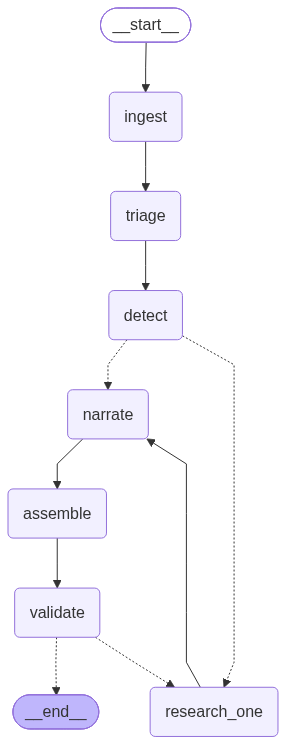

In [15]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

## 10. Run the pipeline → `network_report.json`

In [16]:
run_id = f"run-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
config = {"configurable": {"thread_id": run_id}}

final_state = app.invoke({"log_dir": str(LOG_DIR), "source": f"{SOURCE}:{PCAP.name}"}, config=config)

report = NetworkReport.model_validate(final_state["report"])
REPORT_PATH = WORK / "network_report.json"
REPORT_PATH.write_text(report.model_dump_json(indent=2))
print(f"\nSaved {REPORT_PATH}  |  overall risk: {report.overall_risk.value}  |  findings: {len(report.findings)}")
if final_state.get("errors"):
    print("Validation history:", final_state["errors"])

▶ ingest
▶ triage (LLM)
▶ detect (LLM)
  2 finding(s)
▶ research: fanning out 2 finding(s) in parallel
  F-001: Unencrypted HTTP Traffic to External Hosts
  F-002: High Volume of DNS Queries
▶ narrate (LLM)
▶ assemble
▶ validate
✅ report valid

Saved /content/nsm/network_report.json  |  overall risk: low  |  findings: 2


In [17]:
from IPython.display import Markdown

print(report.executive_summary, "\n")
if report.findings:
    rows = []
    for f in report.findings:
        s = next((s for s in report.solutions if s.finding_id == f.id), None)
        rows.append({"id": f.id, "severity": f.severity.value, "category": f.category.value,
                     "confidence": f.confidence, "title": f.title,
                     "solution_exists": s.solution_exists if s else None,
                     "solution": (s.summary[:90] + "…") if s and len(s.summary) > 90 else (s.summary if s else "")})
    display(pd.DataFrame(rows))
else:
    print("No findings.")

display(Markdown("**Prioritized recommendations**\n\n" + "\n".join(f"{i}. {r}" for i, r in enumerate(report.prioritized_recommendations, 1))))

This network security monitoring report covers a 30.2-second capture period during which 87 connections were observed. The majority of connections were via UDP (61 out of 87), which is unusual as TCP is more commonly used for reliable data transfer. There were 60 DNS queries, with the top domains being github.com, example.com, neverssl.com, www.zeek.org, and docs.zeek.org, suggesting a high level of interest in these domains. HTTP requests were made to both internal and external hosts, and there was one heuristic flag indicating unencrypted HTTP traffic to external hosts. The internal hosts 169.254.169.254, 172.28.0.1, and 172.28.0.12 were involved in significant communication. The overall risk is considered low or informational based on the findings' severities. 



,id,severity,category,confidence,title,solution_exists,solution
0,F-001,low,data_exfiltration,1.0,Unencrypted HTTP Traffic to External Hosts,False,This finding requires further investigation to...
1,F-002,info,malware,1.0,High Volume of DNS Queries,False,The high volume of DNS queries does not have a...


**Prioritized recommendations**

1. Further investigation into the unencrypted HTTP traffic to external hosts is recommended.
2. Monitor the high volume of DNS queries to ensure they are legitimate and not part of a larger attack.

In [18]:
print(report.model_dump_json(indent=2))

{
  "report_id": "f1096544-2e36-4c5f-862e-48d8feca39e5",
  "generated_at": "2026-09-29T10:52:54.838899+00:00",
  "source": "live:live.pcap",
  "zeek_version": "zeek version 9.0.0",
  "model": "vllm:Qwen/Qwen2.5-7B-Instruct-AWQ",
  "capture_summary": {
    "total_connections": 87,
    "duration_seconds": 30.2,
    "top_protocols": [
      "udp",
      "tcp"
    ],
    "top_services": [
      "dns",
      "-",
      "ssl",
      "http"
    ],
    "internal_hosts": [
      "169.254.169.254",
      "172.28.0.1",
      "172.28.0.12"
    ],
    "external_host_count": 9,
    "dns_queries": 60,
    "http_requests": 8,
    "tls_sessions": 9,
    "zeek_notices": 0,
    "heuristic_flag_count": 1
  },
  "heuristic_flags": [
    {
      "rule": "plaintext_http_to_external",
      "hosts": [
        "172.28.0.12"
      ],
      "detail": "4 unencrypted HTTP requests to external hosts (example.com, neverssl.com, gpu-t4-s-kkb-usw1b1-14canyr1ygfi5.us-west1-b.c.codatalab-user-runtimes.internal:8007)"
  

In [21]:
try:
    from google.colab import files
    files.download(str(REPORT_PATH))
except Exception as e:
    print("Not in Colab, report is at", REPORT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Continuous monitoring loop


In [24]:
MONITOR_ROUNDS = 3
ROUND_SECONDS = 30

monitor_history = []
for i in range(MONITOR_ROUNDS):
    print(f"\n=== round {i+1}/{MONITOR_ROUNDS} ===")
    pcap_i = capture_live(ROUND_SECONDS, WORK / f"round_{i+1}.pcap")
    logs_i = run_zeek(pcap_i, WORK / f"zeek_logs_round_{i+1}")
    cfg = {"configurable": {"thread_id": f"monitor-round-{i+1}"}}
    st = app.invoke({"log_dir": str(logs_i), "source": f"live-round-{i+1}"}, config=cfg)
    rep = NetworkReport.model_validate(st["report"])
    out = WORK / f"network_report_round_{i+1}.json"
    out.write_text(rep.model_dump_json(indent=2))
    monitor_history.append({"round": i + 1, "risk": rep.overall_risk.value, "findings": len(rep.findings),
                            "connections": rep.capture_summary.total_connections, "report": str(out)})

if monitor_history:
    display(pd.DataFrame(monitor_history))


=== round 1/3 ===
Capturing 30s on eth0 -> /content/nsm/round_1.pcap
Saved /content/nsm/round_1.pcap (1,904,870 bytes)
Zeek logs: capture_loss.log, conn.log, dns.log, files.log, http.log, known_hosts.log, known_services.log, loaded_scripts.log, packet_filter.log, software.log, ssl.log, stats.log, weird.log
▶ ingest
▶ triage (LLM)
▶ detect (LLM)
  2 finding(s)
▶ research: fanning out 2 finding(s) in parallel
  F-001: Unencrypted HTTP Requests to External Hosts
  F-002: High Volume of DNS Queries
▶ narrate (LLM)
▶ assemble
▶ validate
  ✅ report valid

=== round 2/3 ===
Capturing 30s on eth0 -> /content/nsm/round_2.pcap
Saved /content/nsm/round_2.pcap (1,912,272 bytes)
Zeek logs: capture_loss.log, conn.log, dns.log, files.log, http.log, known_hosts.log, known_services.log, loaded_scripts.log, packet_filter.log, software.log, ssl.log, stats.log, weird.log
▶ ingest
▶ triage (LLM)
▶ detect (LLM)
  2 finding(s)
▶ research: fanning out 2 finding(s) in parallel
  F-001: Potential Data Exfiltra

,round,risk,findings,connections,report
0,1,low,2,111,/content/nsm/network_report_round_1.json
1,2,high,2,110,/content/nsm/network_report_round_2.json
2,3,medium,2,111,/content/nsm/network_report_round_3.json
